## 1. Общий пайплайн

```
данные → очистка → токенизация → обучение GPT-2 → оценка → чат-интерфейс → анализ
```

## 2. Основные технические ориентиры

* Модель: `GPT2LMHeadModel`
* Токенизатор: `GPT2Tokenizer`
* Оптимизация: `AdamW` + `linear scheduler`
* Базовые гиперпараметры:

  * `batch_size = 8`
  * `epochs = 3`
  * `lr = 5e-5`

## 3. Критичные этапы (с точки зрения качества)

* Очистка данных (сильно влияет на результат)
* Корректное разбиение train/val/test
* Контроль переобучения через `val_loss` и `perplexity`
* Настройка генерации (`top_k`, `top_p`, `temperature` при необходимости)

## 4. Метрики оценки

* **Perplexity** — основная для языковой модели
* **BLEU / ROUGE** — вспомогательные
* * ручная оценка

## 5. Практическая часть

* Реализация цикла обучения с логированием
* Сравнение оптимизаторов
* Построение графиков:

  * loss vs epoch
  * perplexity vs epoch

## 6. Финальный результат

* Обученная модель
* Консольный чат-бот
* Отчёт с анализом


# Загрузка и сбор текста


In [45]:
import os

DATA_PATH = "data/"

lines_file = os.path.join(DATA_PATH, "movie_lines.txt")
conv_file = os.path.join(DATA_PATH, "movie_conversations.txt")

In [46]:
def load_lines(path):
    id2line = {}
    
    with open(path, encoding="iso-8859-1") as f:
        for line in f:
            parts = line.split(" +++$+++ ")
            if len(parts) == 5:
                line_id = parts[0]
                text = parts[4].strip()
                id2line[line_id] = text
                
    return id2line

id2line = load_lines(lines_file)

print("Количество реплик:", len(id2line))
print("Пример:", list(id2line.items())[0])

Количество реплик: 304713
Пример: ('L1045', 'They do not!')


In [47]:
import ast

def load_conversations(path, id2line):
    conversations = []
    
    with open(path, encoding="iso-8859-1") as f:
        for line in f:
            parts = line.split(" +++$+++ ")
            if len(parts) == 4:
                line_ids = ast.literal_eval(parts[3])
                conv = [id2line[line_id] for line_id in line_ids if line_id in id2line]
                conversations.append(conv)
                
    return conversations

conversations = load_conversations(conv_file, id2line)

print("Диалогов:", len(conversations))
print("Пример диалога:", conversations[0][:3])

Диалогов: 83097
Пример диалога: ['Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.', "Well, I thought we'd start with pronunciation, if that's okay with you.", 'Not the hacking and gagging and spitting part.  Please.']


# Базовая очистка текста

In [48]:
import re

def clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Разворачивание корпуса в список

In [49]:
all_texts = []

for conv in conversations:
    for utt in conv:
        if utt:
            all_texts.append(clean(utt))

print("Всего реплик:", len(all_texts))

Всего реплик: 304446


# Статистика корпуса

In [50]:
import numpy as np

lengths = [len(t.split()) for t in all_texts]

print("Средняя длина:", np.mean(lengths))
print("Медиана:", np.median(lengths))
print("Максимум:", np.max(lengths))

Средняя длина: 10.544582618920925
Медиана: 7.0
Максимум: 556


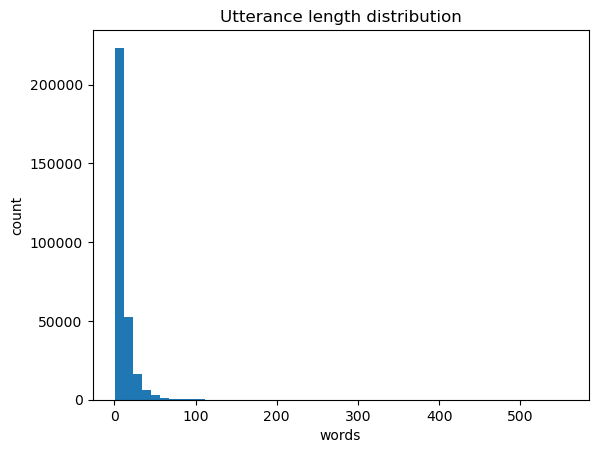

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Utterance length distribution")
plt.xlabel("words")
plt.ylabel("count")
plt.show()

In [52]:
from collections import Counter

tokens = " ".join(all_texts).split()
counter = Counter(tokens)

print(counter.most_common(20))

[('you', 107035), ('i', 99932), ('the', 98316), ('to', 78601), ('a', 70244), ('and', 44266), ('of', 38671), ('in', 32135), ('it', 29350), ('that', 26939), ('what', 26726), ('is', 26378), ("don't", 23401), ('for', 22178), ("i'm", 22002), ('have', 20857), ('your', 20810), ('my', 20518), ('this', 20014), ('we', 19906)]


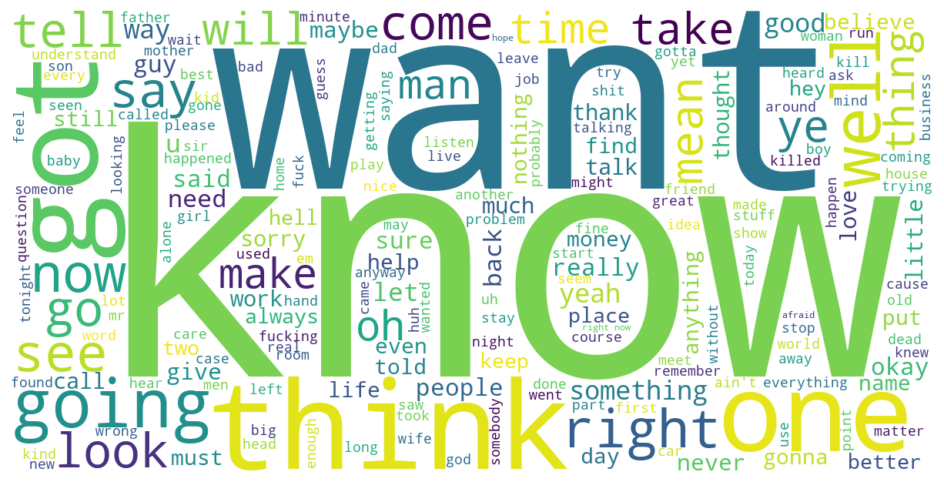

In [53]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_blob = " ".join(all_texts)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(text_blob)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

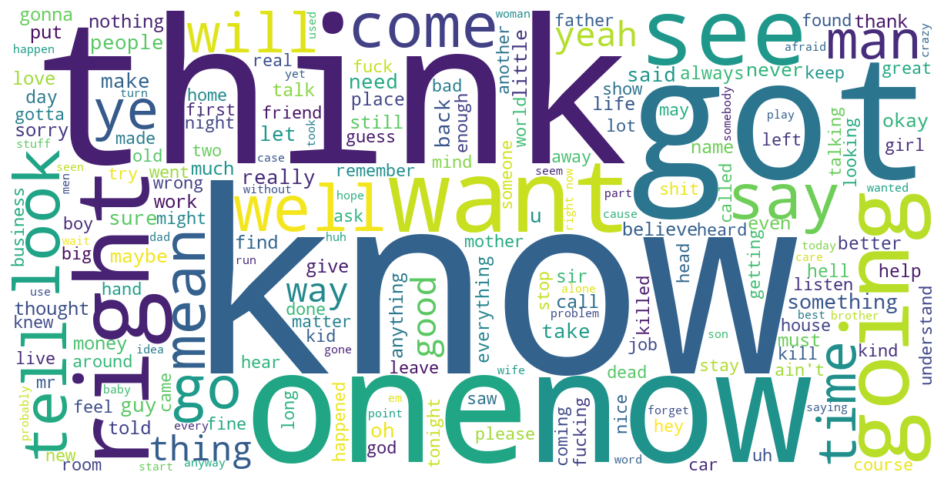

In [54]:
stopwords = {
    "yeah", "yes", "no", "oh", "okay", "ok", "well", "hey",
    "i", "you", "he", "she", "it", "we", "they",
    "a", "an", "the", "to", "of", "and", "in"
}

filtered_tokens = [t for t in tokens if t not in stopwords]

wc2 = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(" ".join(filtered_tokens))

plt.figure(figsize=(12,6))
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.show()

# NLTK stopwords

In [55]:
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/penguin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/penguin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [56]:
original_tokens = " ".join(all_texts).lower().split()

# Stopwords + Lemmatization

In [57]:
def lemmatize_tokens(text):
    text = clean(text)
    tokens = text.split()

    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

lem_tokens = []
for t in all_texts:
    lem_tokens.extend(lemmatize_tokens(t))

# Stemming

In [58]:
def stem_tokens_func(text):
    text = clean(text)
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

stem_tokens_list = []
for t in all_texts:
    stem_tokens_list.extend(stem_tokens_func(t))

# Сравнение методов

In [59]:
def vocab_size(tokens):
    return len(set(tokens))

print("Original vocab:", vocab_size(original_tokens))
print("Lemmatized vocab:", vocab_size(lem_tokens))
print("Stemmed vocab:", vocab_size(stem_tokens_list))

Original vocab: 140938
Lemmatized vocab: 136543
Stemmed vocab: 128884


| метод         | пример         |
| ------------- | -------------- |
| original      | "running"      |
| stemming      | "run" / "runn" |
| lemmatization | "run"          |


# Top-20 слов (lemmatized)

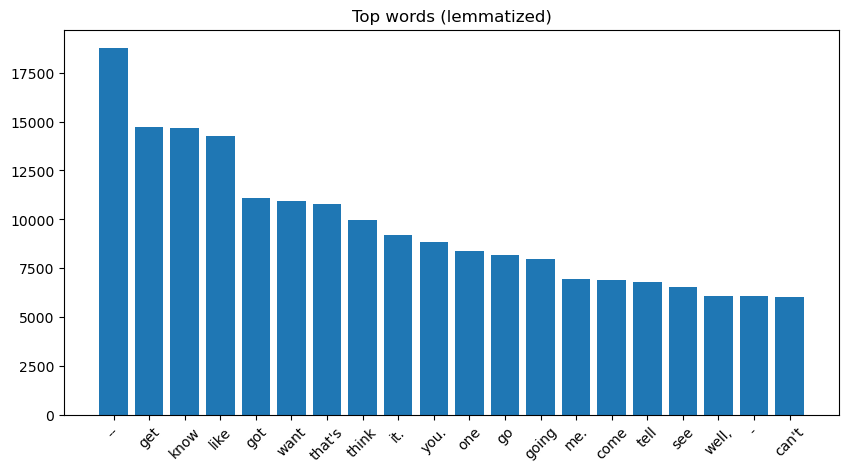

In [60]:
counter = Counter(lem_tokens)

words, counts = zip(*counter.most_common(20))

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top words (lemmatized)")
plt.show()

# N-grams анализ (контекст слов)

In [61]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(all_texts)

print(vectorizer.get_feature_names_out())

['didn know' 'don care' 'don know' 'don like' 'don need' 'don think'
 'don understand' 'don want' 'don worry' 'just like' 'll tell' 'look like'
 'looks like' 'new york' 'oh god' 'oh yeah' 've got' 've seen' 'want know'
 'yes sir']


# TF-IDF

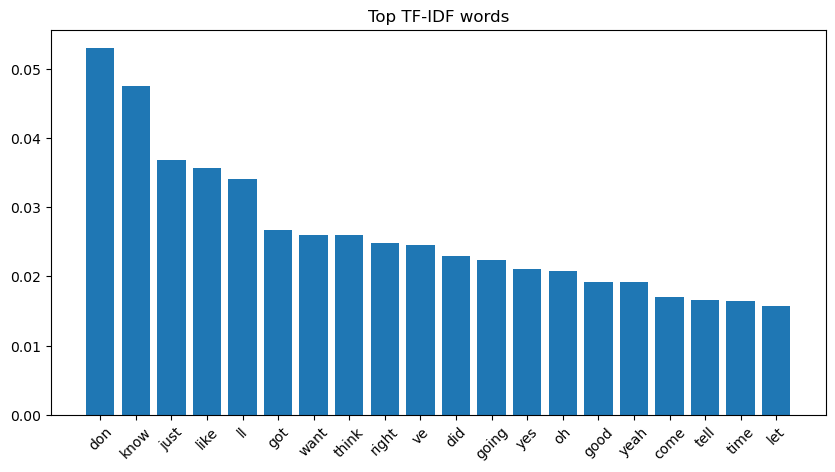

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = tfidf.fit_transform(all_texts)

feature_names = tfidf.get_feature_names_out()
scores = X.mean(axis=0).A1

top_idx = np.argsort(scores)[::-1][:20]

plt.figure(figsize=(10,5))
plt.bar([feature_names[i] for i in top_idx],
        [scores[i] for i in top_idx])
plt.xticks(rotation=45)
plt.title("Top TF-IDF words")
plt.show()

# Диалоговые слова

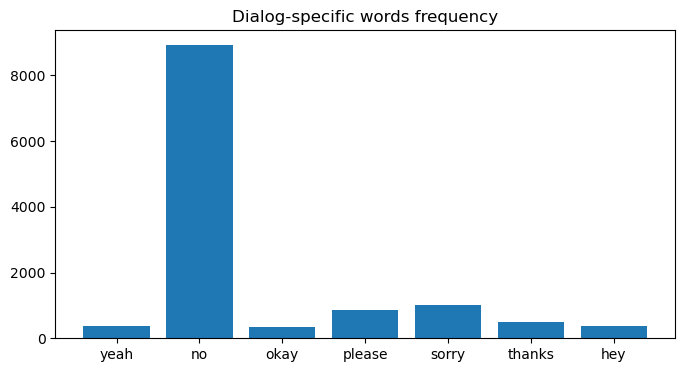

In [63]:
dialog_words = ["yeah", "no", "okay", "please", "sorry", "thanks", "hey"]

dialog_freq = {w: original_tokens.count(w) for w in dialog_words}

plt.figure(figsize=(8,4))
plt.bar(dialog_freq.keys(), dialog_freq.values())
plt.title("Dialog-specific words frequency")
plt.show()

# Анализ корпуса показал:

1. После лемматизации и удаления stopwords существенно сокращается размер словаря,
что снижает шум и улучшает интерпретируемость данных.

2. Stemming даёт более агрессивное сокращение слов,
но может приводить к потере семантической точности.

3. N-gram анализ выявляет устойчивые разговорные конструкции,
характерные для естественного диалога.

4. TF-IDF позволяет выделить значимые слова,
отличающиеся от просто частотных.

5. Частотный анализ подтверждает наличие разговорной структуры речи,
что делает корпус подходящим для обучения диалоговой GPT-модели.

In [64]:
conversations


[['Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.',
  "Well, I thought we'd start with pronunciation, if that's okay with you.",
  'Not the hacking and gagging and spitting part.  Please.',
  "Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?"],
 ["You're asking me out.  That's so cute. What's your name again?",
  'Forget it.'],
 ["No, no, it's my fault -- we didn't have a proper introduction ---",
  'Cameron.',
  "The thing is, Cameron -- I'm at the mercy of a particularly hideous breed of loser.  My sister.  I can't date until she does.",
  'Seems like she could get a date easy enough...'],
 ['Why?',
  'Unsolved mystery.  She used to be really popular when she started high school, then it was just like she got sick of it or something.',
  "That's a shame."],
 ['Gosh, if only we could find Kat a boyfriend...',
  'Let me see what I can do.'],
 ["C'esc ma tete. This is my head"

In [65]:
all_texts

['can we make this quick? roxanne korrine and andrew barrett are having an incredibly horrendous public break- up on the quad. again.',
 "well, i thought we'd start with pronunciation, if that's okay with you.",
 'not the hacking and gagging and spitting part. please.',
 "okay... then how 'bout we try out some french cuisine. saturday? night?",
 "you're asking me out. that's so cute. what's your name again?",
 'forget it.',
 "no, no, it's my fault -- we didn't have a proper introduction ---",
 'cameron.',
 "the thing is, cameron -- i'm at the mercy of a particularly hideous breed of loser. my sister. i can't date until she does.",
 'seems like she could get a date easy enough...',
 'why?',
 'unsolved mystery. she used to be really popular when she started high school, then it was just like she got sick of it or something.',
 "that's a shame.",
 'gosh, if only we could find kat a boyfriend...',
 'let me see what i can do.',
 "c'esc ma tete. this is my head",
 "right. see? you're ready f

# Построение контекстных окон

In [67]:
def build_windows(conversations, window_size=4):
    samples = []

    for conv in conversations:
        conv = [clean(x) for x in conv if x]

        if len(conv) < 2:
            continue

        for i in range(1, len(conv)):
            start = max(0, i - window_size)
            context = conv[start:i]
            target = conv[i]

            samples.append((context, target))

    return samples

samples = build_windows(conversations, window_size=4)

print("Samples:", len(samples))
print("Example:", samples[0])

Samples: 221367
Example: (['can we make this quick? roxanne korrine and andrew barrett are having an incredibly horrendous public break- up on the quad. again.'], "well, i thought we'd start with pronunciation, if that's okay with you.")


# Преобразование в GPT формат

In [68]:
SEP = " [SEP] "

def to_text(context, target):
    return SEP.join(context + [target])

dataset_texts = [to_text(c, t) for c, t in samples]

print(dataset_texts[0])

can we make this quick? roxanne korrine and andrew barrett are having an incredibly horrendous public break- up on the quad. again. [SEP] well, i thought we'd start with pronunciation, if that's okay with you.


In [94]:
import torch
import math
from datetime import datetime
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

# Ограничение датасета

In [92]:
dataset_texts = dataset_texts[:50000]

# Токенизация GPT-2

In [93]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Dataset

In [95]:
class GPT2DialogDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": enc["input_ids"].squeeze(0)
        }

dataset = GPT2DialogDataset(dataset_texts, tokenizer)

# DataLoader

In [108]:
train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# Модель GPT-2

In [75]:
from transformers import GPT2LMHeadModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GPT2LMHeadModel.from_pretrained("gpt2")
model.to(device)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2855.87it/s]


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [97]:
import transformers
import torch

print(transformers.__version__)
print(torch.__version__)

5.5.4
2.9.1


# Оптимизатор (AdamW)

In [98]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=0.01
)

# Scheduler (linear warmup)

In [99]:
from transformers import get_linear_schedule_with_warmup

epochs = 3
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Mixed Precision 

In [104]:
scaler = GradScaler()

/tmp/ipykernel_5437/4292142752.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [100]:
print(len(dataset_texts))

50000


In [105]:
import torch
print(torch.cuda.is_available())

True


In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Training loop

In [109]:
train_losses = []

model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Perplexity: {math.exp(avg_loss):.2f}")
    print("-" * 30)

/tmp/ipykernel_5437/2694714053.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

# График обучения

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Сохранение модели

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_path = f"model/gpt2-dialog-model_{timestamp}"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Saved to:", save_path)

# Проверка

In [ ]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

model.eval()

def generate_response(text):
    inputs = tokenizer(text, return_tensors="pt").to(device)

    output = model.generate(
        **inputs,
        max_length=80,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

print(generate_response("hello"))